The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
0.125 0.3
2/3

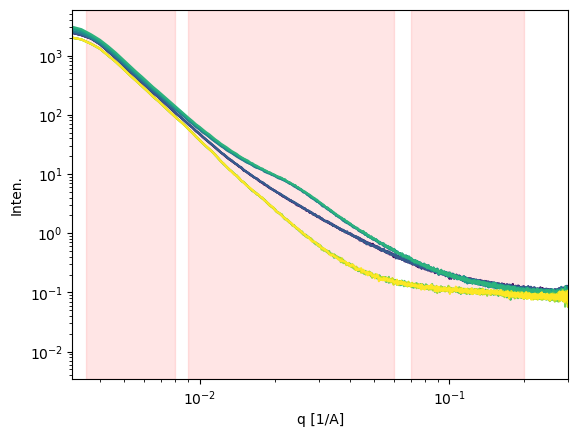

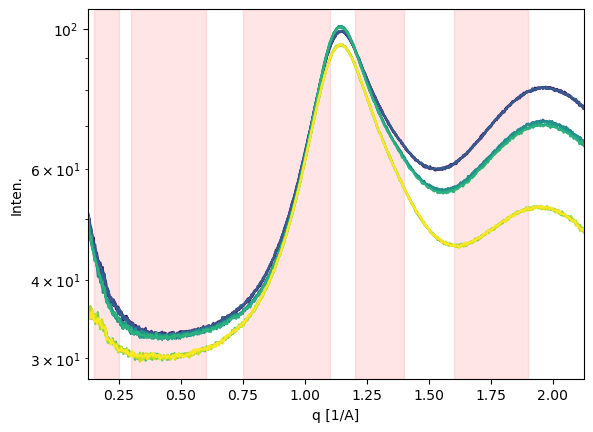

In [104]:
%load_ext autoreload
%autoreload 2
import src


import numpy as np
import matplotlib.pyplot as plt
e = src.const.EIGER_QRANGE
p = src.const.PILATUS_QRANGE

print(p[0], e[-1])



tp1e = src.ComboScan(scan_ids = [102688,102689, 102690], det='eiger')
tp1p = src.ComboScan(scan_ids = [102688,102689, 102690], det='pilatus')

tp1e.plot_iq()
for band in src.const.EIGER_QBANDS:
    plt.axvspan(band[0], band[1], color='red', alpha=0.1)
tp1p.plot_iq()
for band in src.const.PILATUS_QBANDS:
    plt.axvspan(band[0], band[1], color='red', alpha=0.1)

(0.01, 0.1)

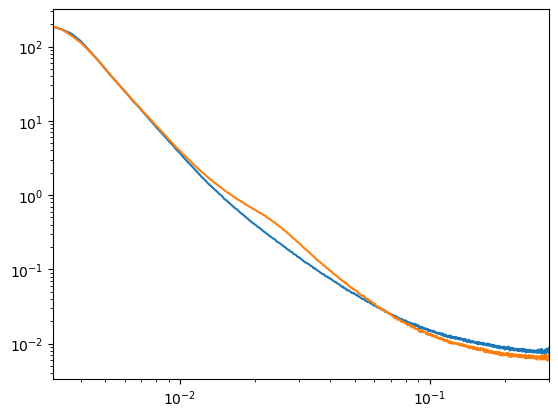

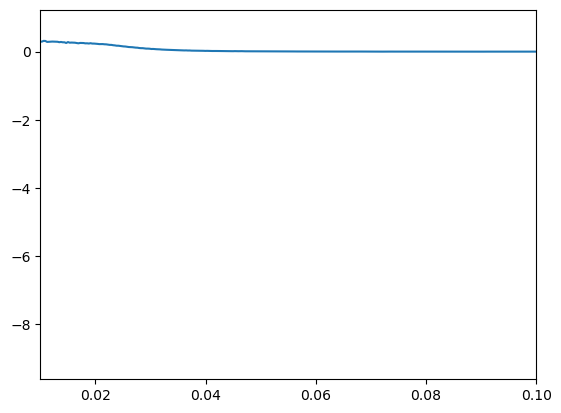

In [17]:
s1 = src.Scan(102688, 'eiger')
s2 = src.Scan(102689, 'eiger')

q_mask = (s1.qs>=src.const.EIGER_QBANDS[1][0]) & (s1.qs<=src.const.EIGER_QBANDS[1][1])
q_mask = (s1.qs>=src.const.EIGER_QRANGE[0]) & (s1.qs<=src.const.EIGER_QRANGE[1])
s1_norm = np.mean(s1.Is_mean[q_mask])
s2_norm = np.mean(s2.Is_mean[q_mask])


plt.figure()
plt.plot(s1.qs, s1.Is_mean/s1_norm)
plt.plot(s1.qs, s2.Is_mean/s2_norm)
plt.yscale('log')
plt.xscale('log')
plt.xlim(src.const.EIGER_QRANGE)
plt.figure()
plt.plot(s1.qs, s2.Is_mean/s2_norm - s1.Is_mean/s1_norm)
plt.xlim([0.01, 0.1])
#plt.yscale('log')
#plt.xscale('log')

In [133]:
%load_ext autoreload
%autoreload 2
import src
import numpy as np
import matplotlib.pyplot as plt

first_prot_scan_ids = [i for i in range(102628, 102688)]
tp1_sid = first_prot_scan_ids[::2]
tp5_sid = first_prot_scan_ids[1::2]

second_prot_scan_ids = [i for i in range(102688, 102724)]
tp1_sid += second_prot_scan_ids[::3]
tp3_sid = second_prot_scan_ids[1::3]
tp5_sid += second_prot_scan_ids[2::3]





The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


11/12

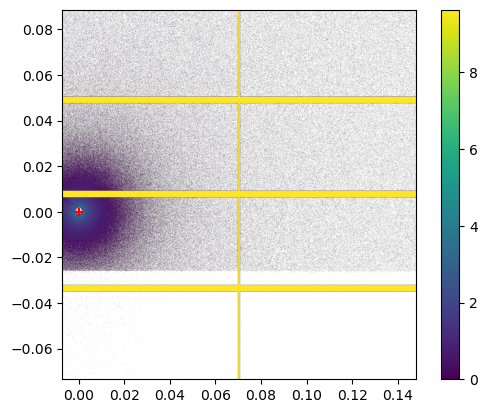

In [151]:
tp1=src.ComboScan(tp1_sid[30:], det='eiger')
tp1.plot_img(i=25,log=True)

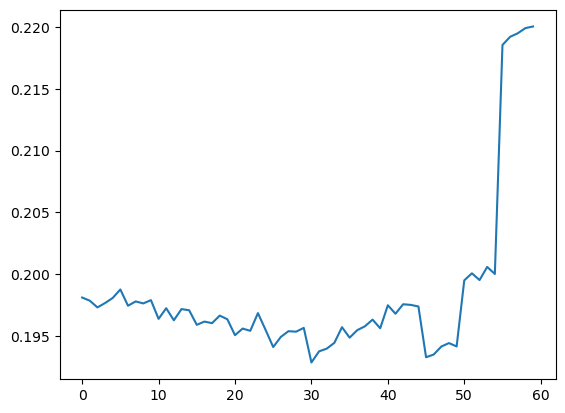

In [155]:
plt.figure()
plt.plot(tp1.it)


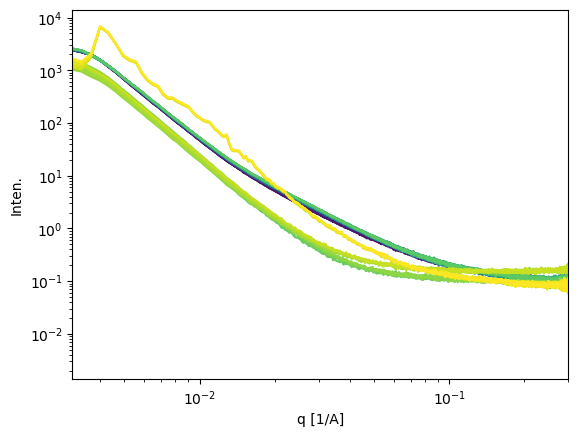

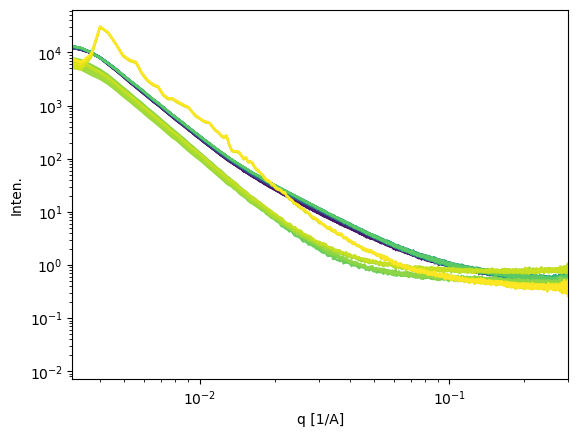

In [153]:
tp1.plot_iq()
tp1.Is = tp1.Is/tp1.it[:,None]
tp1.plot_iq()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


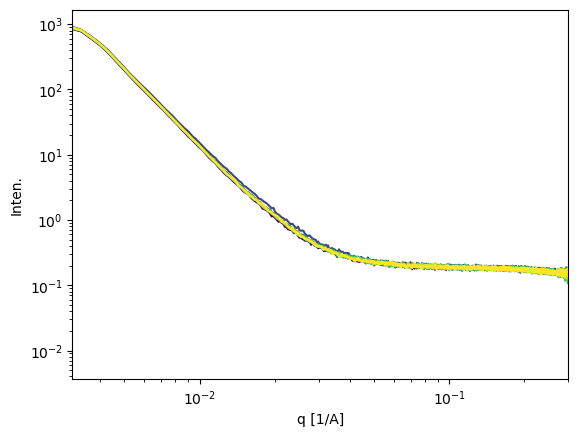

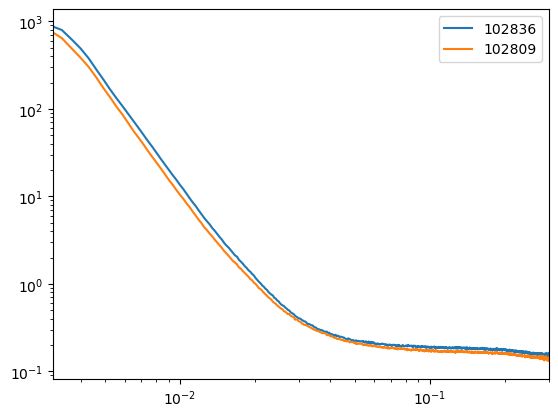

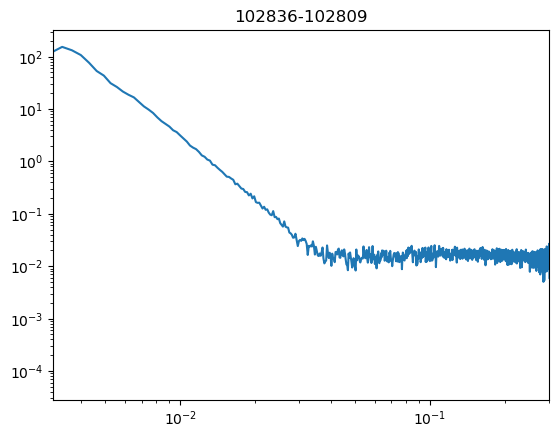

In [102]:
%load_ext autoreload
%autoreload 2
import src
import numpy as np
import matplotlib.pyplot as plt

for sid in (102836,):
    s1 = src.Scan(sid, det='eiger')
    s2 = src.Scan(102809, det='eiger')
    
    #s1.plot_iq()
    s1.plot_iq(logX=True)
    
    plt.figure()
    plt.plot(s1.qs, s1.Is_mean, label=s1.scan_id)
    plt.plot(s1.qs, s2.Is_mean, label=s2.scan_id)
    plt.yscale('log')
    plt.xscale('log')
    plt.xlim(src.const.EIGER_QRANGE)
    #plt.xlim(src.const.PILATUS_QRANGE)
    plt.legend()
    
    
    plt.figure()
    plt.plot(s1.qs, np.abs(s1.Is_mean - s2.Is_mean))
    plt.xlim(src.const.EIGER_QRANGE)
    #plt.xlim(src.const.PILATUS_QRANGE)
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f'{s1.scan_id}-{s2.scan_id}')
#
#plt.xlim(

0/1

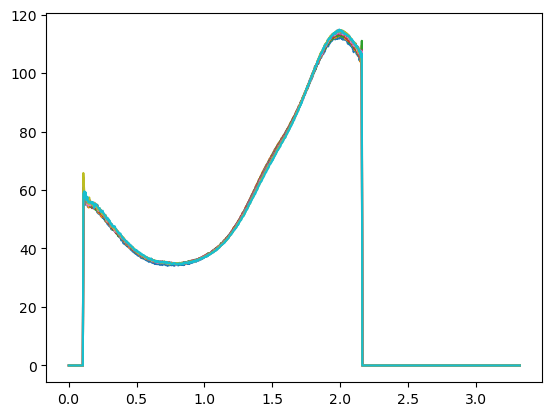

In [100]:
empty = src.ComboScan([102830,], det='pilatus')
plt.figure()
for i in range(1,empty.Is.shape[0]):
    plt.plot(empty.qs, empty.Is[i,:])

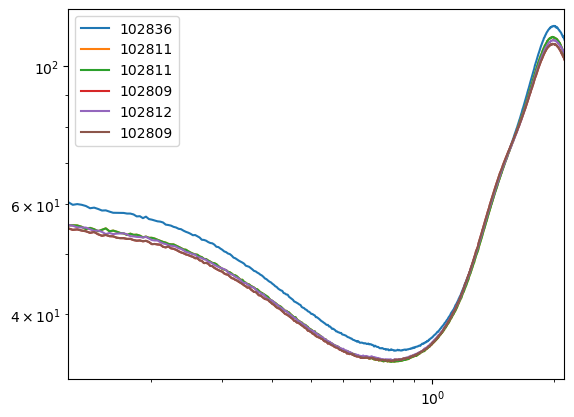

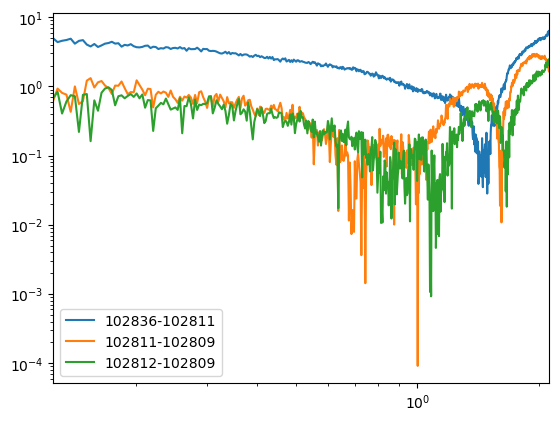

In [101]:


f1, ax1 = plt.subplots(1,1)
f2, ax2 = plt.subplots(1,1)
for sid1, sid2 in [(102836,102811), (102811, 102809), (102812, 102809)] :
    s1 = src.Scan(sid1, det='pilatus')
    s2 = src.Scan(sid2, det='pilatus')
    
    #s1.plot_iq()
    #s1.plot_iq(logX=True)
    #plt.title(s1.scan_id)
    
    
    ax1.plot(s1.qs, s1.Is_mean, label=s1.scan_id)
    
    ax1.plot(s1.qs, s2.Is_mean, label=s2.scan_id)
    ax1.set_yscale('log')
    ax1.set_xscale('log')
    ax1.set_xlim(src.const.EIGER_QRANGE)
    ax1.set_xlim(src.const.PILATUS_QRANGE)
    ax1.legend()
    
    
    
    ax2.plot(s1.qs, np.abs(s1.Is_mean - s2.Is_mean), label=f'{s1.scan_id}-{s2.scan_id}')
    ax2.set_xlim(src.const.EIGER_QRANGE)
    ax2.set_xlim(src.const.PILATUS_QRANGE)
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.legend()
    #plt.title(f'{s1.scan_id}-{s2.scan_id}')